In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import os
import time

from collections.abc import Callable
from dataclasses import asdict
from pathlib import Path
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler
from torch.optim import Adam
from tqdm import tqdm

from experiments.plotting import (
    _plot_SRE_distribution,
    plot_training_curves,
    view_correlation,
)
from GNN.parameter_search.helpers import objective_GNN, objective_NN
from GNN.physics_aware_NN import GNN, NN, Regressor
from GNN.training.datasets import build_loaders, build_loaders_NN
from GNN.training.train import build_loss, train_model
from GNN.training.train_config import TrainConfig
from GNN.training.utils import (
    collect_dataset_indices,
    collect_dataset_paths,
    evaluate_loss,
    evaluate_r2,
    to_scalar,
    unpack_supervised_batch,
)
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

if TYPE_CHECKING:
    from torch_geometric.loader import DataLoader

from GNN.training.train import build_loss, TrainHistory, _run_train_epoch
from GNN.training.runners import _resolve_model_save_path

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [75]:
model_type="gnn"
epochs = 10
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [76]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=None,
    train_hparams=None,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-29 15:46:27,797 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-29 15:46:27,801 - GNN.training.runners - INFO - Training configuration done.
2026-06-29 15:46:27,803 - GNN.training.runners - INFO - Collecting data paths...
2026-06-29 15:46:27,806 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-29 15:46:27,807 - GNN.training.runners - INFO - Data paths collected.
2026-06-29 15:46:27,807 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-29 15:49:04,928 - GNN.training.runners - INFO - Loaders built | train_loader=25704 graphs | val_loader=2856 graphs | test_loader=7140 graphs
2026-06-29 15:49:04,941 - GNN.training.runners - INFO - Loaders and model built.
2026-06-29 15:49:04,941 - GNN.training.runners - INFO - Starting training...
2026-06-29 15:49:04,943 - GNN.training.train - INFO - Using device: cuda
2026-06-29 15:49:35,271 - GNN.training.trai

Epoch 1/10:  27%|██▋       | 54/201 [01:00<02:27,  1.01s/it, loss=0.0266, graphs=7040]

2026-06-29 15:50:35,741 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 55/201 | loss 0.026614 | elapsed 60.4s | graphs 7040


Epoch 1/10:  59%|█████▉    | 119/201 [02:00<01:12,  1.14it/s, loss=0.0146, graphs=15360]

2026-06-29 15:51:35,900 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 120/201 | loss 0.014591 | elapsed 120.6s | graphs 15360


...

2026-06-29 16:20:55,737 - GNN.training.train - INFO - [Heartbeat] Epoch 10 batch 68/201 | loss 0.001332 | elapsed 60.4s | graphs 8704


Epoch 10/10:  68%|██████▊   | 137/201 [02:00<00:51,  1.25it/s, loss=0.0013, graphs=17664]

2026-06-29 16:21:55,977 - GNN.training.train - INFO - [Heartbeat] Epoch 10 batch 138/201 | loss 0.001310 | elapsed 120.6s | graphs 17664


2026-06-29 16:22:51,178 - GNN.training.train - INFO - Training complete (175.8s) | running validation...


2026-06-29 16:23:11,684 - GNN.training.train - INFO - Losses | train 0.001307 | val 0.001028 | lr 9.86e-04 | time train=175.8s val=20.5s total=196.4s
2026-06-29 16:28:16,634 - GNN.training.runners - INFO - Training complete.
2026-06-29 16:28:16,773 - experiments.plotting - INFO - Saved training curve plot to outputs\figures\training_curves\training_curves_gnn_huber_random_10.png
2026-06-29 16:28:16,812 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\random_model_gnn_per_family_sre_density.pt
2026-06-29 16:28:16,971 - scripts.train_model - INFO - Final test loss: 0.001054
2026-06-29 16:28:16,971 - scripts.train_model - INFO - Test R2 score: 0.9668
2026-06-29 16:28:16,973 - scripts.train_model - INFO - Validation R2 score: 0.9693
2026-06-29 16:28:16,973 - scripts.train_model - INFO - Training R2 score: 0.9685


In [77]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = model_save_path
batch_size = 128
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-29 16:31:45,902 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/random_model_gnn_per_family_sre_density.pt
2026-06-29 16:31:45,923 - scripts.predictions - INFO - Using target_variant from checkpoint: sre_density
2026-06-29 16:31:45,943 - scripts.predictions - INFO - Found 1 prediction files


=== Prediction dataset sample ===
target_variant: sre_density
x: torch.Size([13, 43])
global_features: torch.Size([1, 153])
y: tensor([0.0506])
sre: tensor([0.2024])
raw_sre: tensor([0.2024])
n_qubits: tensor([4])
node_in_dim checkpoint: 16
global_in_dim checkpoint: 153
family_projection: random
all_gate_keys len: 151


Predicting (gnn): 100%|██████████| 977/977 [24:08<00:00,  1.48s/batch]
2026-06-29 16:57:19,297 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_random.csv


count    175.000000
mean       4.750045
std        1.991500
min        0.009106
25%        4.602429
50%        5.809698
75%        6.007236
max        6.036439
Name: target_sre, dtype: float64
count    175.000000
mean       4.375305
std        1.796316
min        0.058789
25%        4.454413
50%        5.306775
75%        5.433469
max        5.624756
Name: predicted_sre, dtype: float64


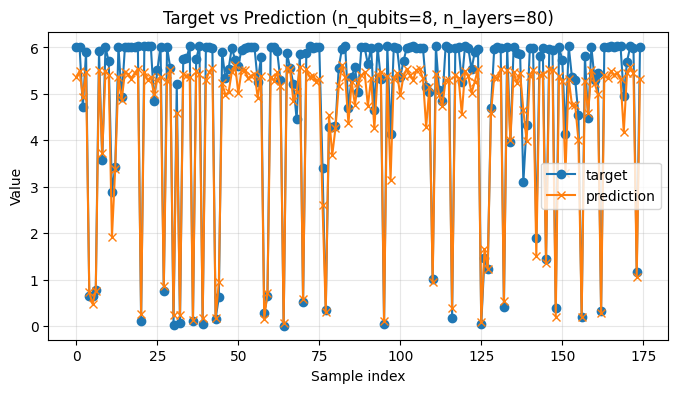

Pearson r = 0.9889


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

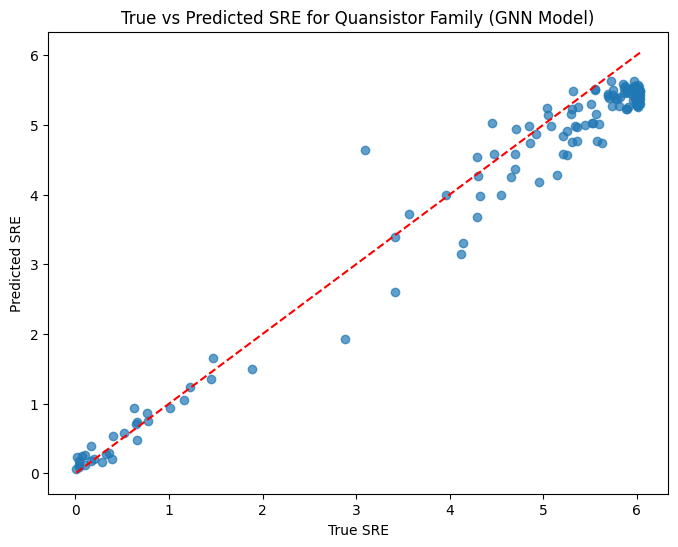

In [86]:
plot_qubits = 8
plot_layers = 80
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
# df = pd.read_csv(f"../notebooks/final/predictions/gnn_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

new_df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]

nq=plot_qubits
nl=plot_layers

if target_variant == "sre_density":
    new_df["target_sre"] = new_df["target_sre"] * nq

print(new_df["target_sre"].describe())
print(new_df["predicted_sre"].describe())



view_correlation(
    new_df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_sre",
    col_y="predicted_sre",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_sre"]*nq, df["predicted_sre"], alpha=0.7)
plt.plot([df["target_sre"].min()*nq, df["target_sre"].max()*nq], [df["target_sre"].min()*nq, df["target_sre"].max()*nq], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

## Test datasets

In [12]:
from GNN.training.datasets import prepare_datasets, make_loaders

In [34]:
family = "haar"
seed = 42
train_split = 0.8
val_split = 0.1
num_workers = 0

In [35]:
family_filter = family if training_mode == "per_family" else None
family_projection = family if training_mode == "per_family" else None

In [36]:
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)

print(f"Collected {len(train_paths)} training paths for family '{family}'.")

Collected 1 training paths for family 'haar'.


In [37]:
prepared = prepare_datasets(
    train_paths,
    loader_kind="gnn",
    seed=seed,
    train_split=train_split,
    val_split=val_split,
    family_projection=family_projection,
    target_variant=target_variant,
    split = split,
)

train_loader, val_loader, test_loader = make_loaders(
    prepared,
    batch_size=batch_size,
    num_workers=num_workers,
)

In [38]:
prepared.base_dataset[0]

Data(
  x=[12, 23],
  edge_index=[2, 8],
  global_features=[1, 2],
  y=[1],
  sre=[1],
  cid='haar_q004_L001_s822089',
  family='haar',
  regime='medium_full',
  n_qubits=[1],
  n_layers=[1],
  seed=[1],
  has_target=[1],
  backend='pennylane',
  method='fwht',
  representation='dense',
  n_bins=[1],
  count_haar_count=[1],
  count_haar_eig_bin_1=[1],
  count_haar_eig_bin_2=[1],
  count_haar_eig_bin_3=[1],
  count_haar_eig_bin_4=[1],
  count_haar_eig_bin_5=[1],
  count_haar_eig_bin_6=[1],
  count_haar_eig_bin_7=[1],
  count_haar_eig_bin_8=[1],
  count_haar_eig_bin_9=[1],
  count_haar_eig_bin_10=[1],
  count_haar_eig_bin_11=[1],
  count_haar_eig_bin_12=[1],
  count_haar_eig_bin_13=[1],
  count_haar_eig_bin_14=[1],
  count_haar_eig_bin_15=[1],
  count_haar_eig_bin_16=[1],
  count_haar_eig_bin_17=[1],
  count_haar_eig_bin_18=[1],
  count_haar_eig_bin_19=[1],
  count_haar_eig_bin_20=[1],
  count_haar_eig_bin_21=[1],
  count_haar_eig_bin_22=[1],
  count_haar_eig_bin_23=[1],
  count_haar_eig

In [44]:
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset
dataset = ShardedQuantumCircuitGraphDataset(["../outputs/temp_data/datasets_SRE/haar/index_haar.jsonl"])
sample = dataset[0]
print("Gate counts:", getattr(sample, 'gate_counts', 'MISSING'))
print("Global features shape:", sample.global_features.shape)

Gate counts: {'haar_count': tensor([0]), 'haar_eig_bin_1': tensor([0]), 'haar_eig_bin_10': tensor([0]), 'haar_eig_bin_11': tensor([0]), 'haar_eig_bin_12': tensor([0]), 'haar_eig_bin_13': tensor([0]), 'haar_eig_bin_14': tensor([0]), 'haar_eig_bin_15': tensor([0]), 'haar_eig_bin_16': tensor([0]), 'haar_eig_bin_17': tensor([0]), 'haar_eig_bin_18': tensor([0]), 'haar_eig_bin_19': tensor([0]), 'haar_eig_bin_2': tensor([0]), 'haar_eig_bin_20': tensor([0]), 'haar_eig_bin_21': tensor([0]), 'haar_eig_bin_22': tensor([0]), 'haar_eig_bin_23': tensor([0]), 'haar_eig_bin_24': tensor([0]), 'haar_eig_bin_25': tensor([0]), 'haar_eig_bin_26': tensor([0]), 'haar_eig_bin_27': tensor([0]), 'haar_eig_bin_28': tensor([0]), 'haar_eig_bin_29': tensor([0]), 'haar_eig_bin_3': tensor([0]), 'haar_eig_bin_30': tensor([0]), 'haar_eig_bin_31': tensor([0]), 'haar_eig_bin_32': tensor([0]), 'haar_eig_bin_33': tensor([0]), 'haar_eig_bin_34': tensor([0]), 'haar_eig_bin_35': tensor([0]), 'haar_eig_bin_36': tensor([0]), 'h